In [119]:
import numpy as np
import polars as pl
import time 
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx

In [46]:
def d_ang(a, b):
    return abs(((a - b + 180) % 360) - 180)

def build_cost_matrix(inc, raan, phase, m):
    n = len(inc)
    C = np.empty((n, n), dtype=float)

    for k in range(n):
        for j in range(n):
            C[k, j] = -((
            m[j]
            - 2 * (d_ang(inc[j], inc[k]) + d_ang(raan[j], raan[k]))
            - d_ang(phase[j], phase[k])
                    
                    
            ))
    np.fill_diagonal(C,np.inf)
    return C

In [183]:
def build_cost_matrix_deluxe(inc, raan, phase, m):
    n = len(inc)
    C = np.empty((n, n), dtype=float)

    for k in range(n):
        for j in range(n):
            C[k, j] = (
           
             2 *np.sin(0.5*(np.deg2rad(d_ang(inc[j], inc[k]))**2 + np.deg2rad(d_ang(raan[j], raan[k]))**2)**0.5)
            + 1 - np.cos(np.deg2rad(d_ang(phase[j], phase[k]))) -2*np.log(1+m[j])        
            )
    np.fill_diagonal(C,np.inf)
    return C

In [184]:
def random_exponential_mass(lam, n, m_min, m_max):
    """
    Genera n muestras de una distribución exponencial truncada decreciente
    en el intervalo [m_min, m_max].

    Parámetros
    ----------
    lam : float
        Tasa de decaimiento (> 0).
    n : int
        Número de muestras.
    m_min : float
        Valor mínimo del intervalo.
    m_max : float
        Valor máximo del intervalo.

    Retorna
    -------
    np.ndarray
        Array de tamaño n con las muestras generadas.
    """
    if lam <= 0:
        raise ValueError("lam debe ser > 0")
    if n <= 0:
        raise ValueError("n debe ser > 0")
    if m_min >= m_max:
        raise ValueError("m_min debe ser menor que m_max")

    u = np.random.rand(n)
    x = m_min - (1 / lam) * np.log(
        1 - u * (1 - np.exp(-lam * (m_max - m_min)))
    )
    return x

In [185]:
data = (
    pl.read_json("data.json")
    .select(
        pl.col("INCLINATION").alias("inc"),
        pl.col("RA_OF_ASC_NODE").alias("raan"),
        pl.col("MEAN_ANOMALY").alias("phase"),
    )
    .with_row_index("id")
)

data.head()
data
# np.shape(data)

id,inc,raan,phase
u32,f64,f64,f64
0,90.2171,69.6901,281.3527
1,90.229,73.6725,267.1339
2,32.1458,28.2816,192.6331
3,89.9959,212.5826,345.3996
4,89.9012,123.3723,32.7967
…,…,…,…
14756,97.538,155.4471,104.9833
14757,97.5373,155.4527,113.5404
14758,97.5381,155.4471,110.3614


In [186]:
# ti = time.time()

result = (
    data
    .filter((pl.col("inc") < 90) == (test[0] < 90)) #Elimina elementos que rotan en direccion contraria a nuestro basurero
    .select([pl.col("id"),
        (pl.col("inc") - test[0]).abs().alias("inc"),
        (((pl.col("raan") - test[1] + 180) % 360) - 180).abs().alias("raan"),
        (((pl.col("phase") - test[2] + 180) % 360) - 180).abs().alias("phase")
        
    ])
    .with_columns(
        (
            pl.lit(200)
            - pl.col("inc")
            - pl.col("phase")
        ).alias("cost")
    )
    .sort("cost", descending=True)
)

result
np.shape(result)
result
# tf = time.time()
# deltat = tf-ti
# print(deltat)

id,inc,raan,phase,cost
u32,f64,f64,f64,f64
4906,4.227398,0.077044,1.237764,190.15335
12978,6.624698,0.449144,0.274664,185.57765
12971,6.627698,0.287444,6.865036,179.304679
12968,6.634298,5.231944,0.316436,175.951079
13135,4.230798,2.958644,10.089136,175.531979
…,…,…,…,…
998,47.620398,179.937444,162.313664,-417.42935
8906,49.106598,171.493456,178.247564,-419.447672
992,47.620198,179.947556,164.432364,-419.567872


In [206]:
# ti = time.time()

result = (
    data
    .filter((pl.col("inc") < 90) == (test[0] < 90)) #Elimina elementos que rotan en direccion contraria a nuestro basurero
    .select([pl.col("id"),
        (pl.col("inc") - test[0]).abs().alias("inc"),
        (((pl.col("raan") - test[1] + 180) % 360) - 180).abs().alias("raan"),
        (((pl.col("phase") - test[2] + 180) % 360) - 180).abs().alias("phase")
        
    ])
    .with_columns(
        (
            pl.lit(1/0.7) #La masa está fija. Queremos incorporar la distribución exponencial que está abajo. La idea es a cada elemento de la lista inicial darle un valor de masa asociado al objeto (ID)
            - 2 * (np.sin(0.5*((np.deg2rad(pl.col("inc"))**2 + np.deg2rad(pl.col("raan"))**2)**0.5)))
            - (1 - np.cos(np.deg2rad(pl.col("phase"))))
        ).alias("cost")
        )
        .sort("cost", descending=True)
)
result
np.shape(result)
result
# tf = time.time()
# deltat = tf-ti
# print(deltat)

id,inc,raan,phase,cost
u32,f64,f64,f64,f64
4906,4.227398,0.077044,1.237764,1.354561
13135,4.230798,2.958644,10.089136,1.323033
9890,4.227698,1.931756,14.197136,1.316926
12978,6.624698,0.449144,0.274664,1.312737
13134,4.227398,3.208144,13.817336,1.307044
…,…,…,…,…
8906,49.106598,171.493456,178.247564,-2.570762
6328,4.227998,179.014856,178.265164,-2.570904
8851,50.202698,173.956744,178.461664,-2.570983


In [68]:
data_100


id,inc,raan,phase
i64,f64,f64,f64
4906,43.0001,242.4212,116.8352
12978,45.3974,242.0491,115.8721
12971,45.4004,242.2108,108.7324
12968,45.407,237.2663,115.281
13135,43.0035,239.5396,105.5083
…,…,…,…
3661,50.004,253.5566,192.1839
13218,43.0041,288.713,95.1281
10447,42.9984,203.6495,80.3428


In [208]:
N = 1000

result_100 = result.head(N)

ids_100_df = result_100.select("id")

data_100 = ids_100_df.join(data, on="id", how="left")

# Asegúrate de que id admite el valor especial del nodo inicial
data_100 = data_100.with_columns(
    pl.col("id").cast(pl.Int64)
)

# Coordenadas de la casilla de salida: ESCALARES
inc0 = float(np.random.rand() * 180)
raan0 = float(np.random.rand() * 360)
phase0 = float(np.random.rand() * 360)

start_row = pl.DataFrame({
    "id": [-1],
    "inc": [inc0],
    "raan": [raan0],
    "phase": [phase0],
})

data_100 = pl.concat([start_row, data_100], how="vertical")

data_100

id,inc,raan,phase
i64,f64,f64,f64
-1,37.104973,318.816352,314.512259
4906,43.0001,242.4212,116.8352
13135,43.0035,239.5396,105.5083
9890,43.0004,244.43,101.4003
12978,45.3974,242.0491,115.8721
…,…,…,…
302,0.0208,221.9835,91.1962
7613,43.0002,203.3866,82.4099
3665,49.9933,253.6805,51.5623


(array([341., 221., 154., 112.,  55.,  45.,  29.,  19.,  18.,   7.]),
 array([0.19602317, 0.79735794, 1.3986927 , 2.00002746, 2.60136223,
        3.20269699, 3.80403175, 4.40536652, 5.00670128, 5.60803604,
        6.20937081]),
 <BarContainer object of 10 artists>)

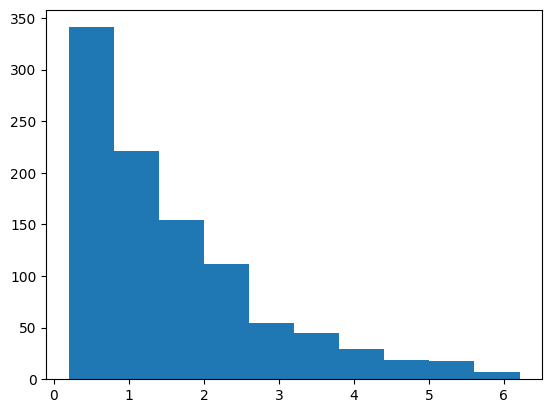

In [209]:
#Mass distribution (Exponential)
# Parámetros
m_min_norm = 0.193 #Masa minima equivalente a 400kg
m_max_norm = 2 * np.pi #Masa maxima equivalente a 13000 kg
lam = 0.7      # tasa de decaimiento; mayor => más concentración cerca de a
#N se ha definido en una celda mas arriba como el numero de muestras que nos quedamos
m = random_exponential_mass(lam, N+1, m_min_norm, m_max_norm)
plt.hist(m)

In [193]:
#Cost matrix (Deluxe :P)
ti = time.time()

inc = data_100["inc"].to_numpy()
raan = data_100["raan"].to_numpy()
phase = data_100["phase"].to_numpy()
costdel = build_cost_matrix_deluxe(inc, raan, phase, m)

# np.shape(cost)
tf = time.time()
print(tf-ti)
# costdel

0.0030264854431152344


In [171]:
# #Cost matrix (Basic)
# ti = time.time()
# # m = 200 * np.ones(data_100.height)

# inc = data_100["inc"].to_numpy()
# raan = data_100["raan"].to_numpy()
# phase = data_100["phase"].to_numpy()

# cost = build_cost_matrix(inc, raan, phase, m)
# cost
# # np.shape(cost)
# tf = time.time()
# print(tf-ti)
# np.size(cost)

0.0009992122650146484


121

In [195]:
def optimal_path_k_steps(C, start, k_steps):
    """
    Encuentra el camino simple de coste mínimo de exactamente k_steps aristas,
    empezando en `start`, sin repetir vértices y sin volver al inicial.

    Parámetros
    ----------
    C : np.ndarray
        Matriz de costes de tamaño (n, n), donde C[i, j] es el coste de i -> j.
    start : int
        Índice del nodo inicial.
    k_steps : int
        Número exacto de aristas del camino.

    Devuelve
    --------
    best_cost : float
        Coste mínimo total.
    best_path : list[int]
        Ruta óptima como lista de índices, incluyendo el nodo inicial.
        Tendrá longitud k_steps + 1.
    """
    C = np.asarray(C, dtype=float)
    n = C.shape[0]

    if C.shape[0] != C.shape[1]:
        raise ValueError("C debe ser una matriz cuadrada.")
    if not (0 <= start < n):
        raise ValueError("`start` está fuera de rango.")
    if k_steps < 1:
        raise ValueError("`k_steps` debe ser >= 1.")
    if k_steps > n - 1:
        raise ValueError("No se pueden dar más de n-1 pasos sin repetir vértices.")

    # Vértices visitables: todos salvo el inicial
    nodes = [v for v in range(n) if v != start]

    # DP[(mask, j)] = mejor coste para:
    # - salir de start
    # - visitar exactamente los nodos de 'mask'
    # - terminar en j
    #
    # mask codifica un subconjunto de `nodes`
    dp = {}
    parent = {}

    # Mapear nodo real -> posición en el bitmask
    pos = {node: idx for idx, node in enumerate(nodes)}

    # Casos base: caminos de 1 arista, start -> j
    for j in nodes:
        mask = 1 << pos[j]
        dp[(mask, j)] = C[start, j]
        parent[(mask, j)] = start

    # Construir caminos de longitud 2, 3, ..., k_steps
    for size in range(2, k_steps + 1):
        new_dp = {}
        new_parent = {}

        for subset in combinations(nodes, size):
            mask = 0
            for v in subset:
                mask |= 1 << pos[v]

            for j in subset:
                prev_mask = mask ^ (1 << pos[j])

                best_cost = np.inf
                best_prev = None

                for i in subset:
                    if i == j:
                        continue

                    cost = dp[(prev_mask, i)] + C[i, j]
                    if cost < best_cost:
                        best_cost = cost
                        best_prev = i

                new_dp[(mask, j)] = best_cost
                new_parent[(mask, j)] = best_prev

        dp = new_dp
        parent.update(new_parent)

    # Elegir mejor final entre todos los subconjuntos de tamaño k_steps
    best_cost = np.inf
    best_state = None

    for subset in combinations(nodes, k_steps):
        mask = 0
        for v in subset:
            mask |= 1 << pos[v]

        for j in subset:
            cost = dp[(mask, j)]
            if cost < best_cost:
                best_cost = cost
                best_state = (mask, j)

    # Reconstrucción de ruta
    mask, j = best_state
    path = [j]

    while True:
        prev = parent[(mask, j)]
        if prev == start:
            path.append(start)
            break
        path.append(prev)
        mask ^= 1 << pos[j]
        j = prev

    path.reverse()
    return best_cost, path

In [197]:

# k_steps = 
start = 0
tvector = []
for i in [1,2,3,4,5,6,7,8,9,10]: 
    ti = time.time()
    best_cost, path = optimal_path_k_steps(costdel, start, i)
    best_cost2, path2 = optimal_path_k_steps(cost, start, i)

    tf = time.time()
    tvector.append(tf-ti)
    print(f"Coste = {best_cost},Camino seguido = {path},Tiempo tardado en computar = {tf-ti} s")
    print(f"Coste_malo = {best_cost2},Camino seguido_malo = {path2},Tiempo tardado en computar_malo = {tf-ti} s")


Coste = -0.7112543073357016,Camino seguido = [0, 10],Tiempo tardado en computar = 0.0010020732879638672 s
Coste_malo = 168.9963635512943,Camino seguido_malo = [0, 4],Tiempo tardado en computar_malo = 0.0010020732879638672 s
Coste = -4.149064580429734,Camino seguido = [0, 2, 10],Tiempo tardado en computar = 0.0009987354278564453 s
Coste_malo = -20.82773644870568,Camino seguido_malo = [0, 4, 2],Tiempo tardado en computar_malo = 0.0009987354278564453 s
Coste = -7.4020445743799765,Camino seguido = [0, 2, 10, 5],Tiempo tardado en computar = 0.002002239227294922 s
Coste_malo = -214.3258364487057,Camino seguido_malo = [0, 4, 2, 1],Tiempo tardado en computar_malo = 0.002002239227294922 s
Coste = -9.853241191525507,Camino seguido = [0, 4, 5, 2, 10],Tiempo tardado en computar = 0.007995128631591797 s
Coste_malo = -407.7671364487057,Camino seguido_malo = [0, 4, 2, 3, 8],Tiempo tardado en computar_malo = 0.007995128631591797 s
Coste = -12.135706920471755,Camino seguido = [0, 4, 5, 2, 3, 10],Tiempo

[0.0, 0.005005359649658203, 0.060564517974853516, 0.862196683883667, 6.669914245605469]


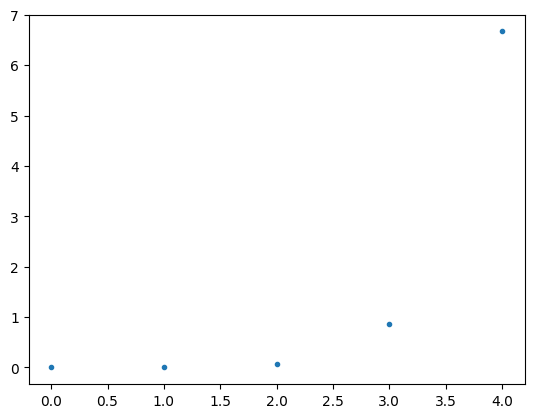

In [116]:
print(tvector)
plt.plot(tvector, '.')

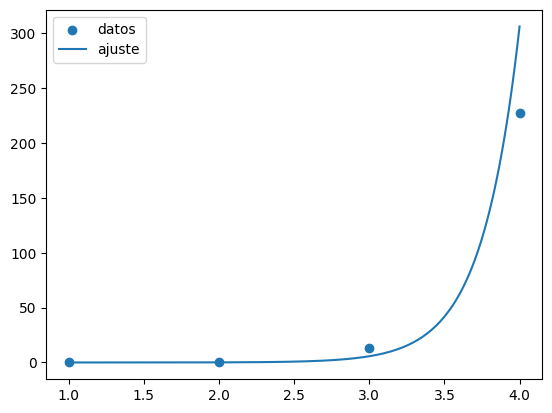

y = 3.6441993606541105e-05 * exp(3.9860789268503596 * x)


In [114]:
# datos
y = np.array([0.0024788379669189453, 0.04912734031677246, 13.047961473464966, 227.30829071998596])
x = np.array([1, 2, 3, 4])

# ajuste exponencial: y = a * exp(bx)
b, log_a = np.polyfit(x, np.log(y), 1)
a = np.exp(log_a)

# curva ajustada
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a * np.exp(b * x_fit)

# plot
plt.scatter(x, y, label="datos")
plt.plot(x_fit, y_fit, label="ajuste")
plt.legend()
plt.show()

print(f"y = {a} * exp({b} * x)")